# Stochastic bundling of Lindblad operators with QuTiP

This tutorial walks through `qutip-bundling`, a small package that implements
the **stochastically bundled dissipator** of

> S. Adhikari and R. Baer, *Stochastically Bundled Dissipators for the Quantum
> Master Equation*, J. Chem. Theory Comput. **2025**, 21, 4142–4150.
> https://doi.org/10.1021/acs.jctc.5c00145

**The problem.** A Lindblad master equation with a large number $N_L$ of
collapse operators is expensive: the dissipator costs one matrix product per
operator, and $N_L$ typically grows as $N^2$ in the Hilbert-space dimension
$N$. Propagating the full equation scales as $O(N^5)$ per step.

**The idea.** The dissipator is *quadratic* in the operators, so it can be
reproduced **in expectation** by a much smaller set of $M$ randomly *bundled*
operators:

$$ R_m = \frac{1}{\sqrt{M}} \sum_\alpha r_{m,\alpha}\, c_\alpha, \qquad
   \mathbb{E}[r_{m,\alpha} r_{m,\beta}^*] = \delta_{\alpha\beta}. $$

Because $\mathbb{E}[r r^*] = I$, the bundled dissipator is an **unbiased
estimator** of the full one for any $M$, and the bundled operators still have
Lindblad form, so the dynamics stay completely positive and trace preserving.
With $M$ independent of $N$, the per-step cost drops to $O(N^3)$.

This notebook covers:
1. Building a system and its Davies/Bohr Lindblad operators
2. Bundling and a first stochastic solve
3. Convergence to the deterministic answer as $M$ grows
4. Bias vs. variance, and the jackknife correction
5. The `native` backend for large systems where `qutip.mesolve` runs out of memory


## 0. Setup

Install with `pip install qutip-bundling` (or `pip install -e .` from a checkout).

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import qutip

import qutip_bundling as qb
print("qutip", qutip.__version__, "| qutip-bundling", qb.__version__)

qutip 5.3.0 | qutip-bundling 0.5.0


## 1. A system with many Lindblad operators

We take an anharmonic oscillator coupled to a two-level spin, with the
oscillator position $x$ coupling to a thermal (ohmic) bath. Because the
eigenbasis is non-trivial, *every pair of energy levels* contributes a
Davies/Bohr Lindblad operator — so the operator count grows quickly with the
Hilbert-space dimension. This is exactly the regime bundling targets.

In [2]:
N_FOCK = 8                       # oscillator levels
OMEGA0, KT, ALPHA, OMEGA_C = 1.0, 0.5, 0.4, 5.0
SPIN_GAP, COUPLING = 1.0, 0.3

a = qutip.destroy(N_FOCK)
n = a.dag() * a
x = (a + a.dag()) / math.sqrt(2.0)
sz, sx = qutip.sigmaz(), qutip.sigmax()
I_o, I_s = qutip.qeye(N_FOCK), qutip.qeye(2)

# System Hamiltonian (anharmonic oscillator + spin + coupling)
H = (OMEGA0 * qutip.tensor(n + 0.5, I_s)
     + 0.1 * qutip.tensor(n * n, I_s)
     + 0.5 * SPIN_GAP * qutip.tensor(I_o, sz)
     + COUPLING * qutip.tensor(x, sx))

# Operator through which the bath couples
X = qutip.tensor(x, I_s)

print("Hilbert dimension:", H.shape[0])

Hilbert dimension: 16


### The bath spectral function

A detailed-balance ohmic $\gamma(\omega)$ ensures the system relaxes to the
Gibbs state at temperature $k_BT$. **The sign convention matters**: with
$\omega = E_b - E_a$ for an operator $|a\rangle\langle b|$, a downward
(energy-releasing) transition has $\omega > 0$, and $\gamma$ should be large
there. `davies_operators` (next cell) bakes this in for you.

In [3]:
def gamma(omega):
    """Ohmic spectral function with detailed balance."""
    if abs(omega) < 1e-10:
        return ALPHA * KT
    return ALPHA * omega * math.exp(-abs(omega) / OMEGA_C) / (1.0 - math.exp(-omega / KT))

## 2. Build the collapse operators — the safe way

`davies_operators(H, X, gamma)` diagonalizes $H$, forms the Bohr-frequency
operators $\langle a|X|b\rangle\,|a\rangle\langle b|$, weights them by
$\sqrt{\gamma(\omega)}$, and uses the correct sign so the system relaxes
**downward** in energy. This is the recommended entry point.

In [4]:
c_ops_full = qb.davies_operators(H, X, gamma)
print("Number of collapse operators:", len(c_ops_full))

Number of collapse operators: 128


### Optional: build-time sparsity threshold

The default above keeps the full Davies/Lindblad operator set. For large systems
you can also prune weak Bohr-pair couplings while constructing the original
operator list:

```python
c_ops_sparse = qb.davies_operators(
    H, X, gamma,
    coupling_threshold=1e-6,
)
print(len(c_ops_sparse), "retained out of", len(c_ops_full))
```

This is **not** the same knob as the bundle size `M`. `coupling_threshold`
changes how many original operators are retained in the Lindblad equation; `M`
controls how many bundled operators approximate the retained list. For validation,
start with `coupling_threshold=0.0`, then raise it only after checking that your
observables do not change beyond your tolerance.

## 3. Bundle, and a first stochastic solve

`bundle(c_ops, M)` returns $M$ bundled operators. We hand them to QuTiP's
`mesolve` exactly like ordinary collapse operators. We start the system in an
excited state and watch it relax.

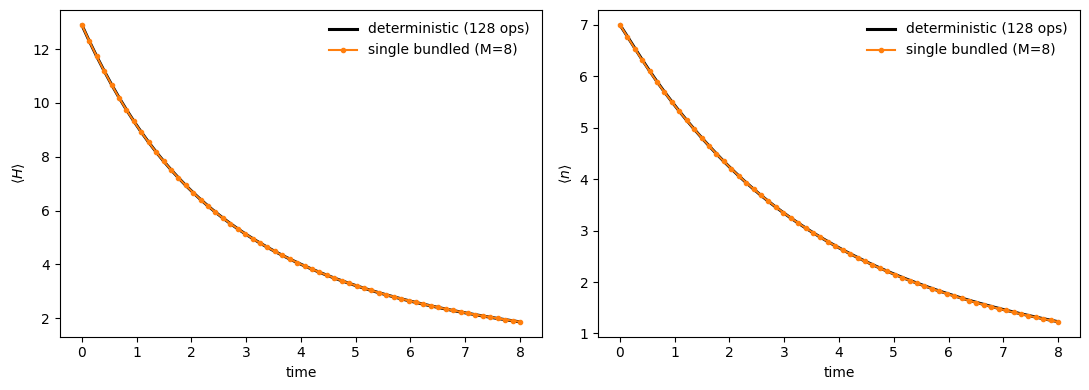

In [5]:
rho0 = qutip.ket2dm(qutip.tensor(qutip.basis(N_FOCK, N_FOCK - 1),
                                  qutip.basis(2, 0)))
tlist = np.linspace(0, 8, 60)
e_ops = [H, qutip.tensor(n, I_s)]

# Deterministic reference (all operators)
det = qutip.mesolve(H, rho0, tlist, c_ops=c_ops_full, e_ops=e_ops)

# One bundled realization with M = 8
R = qb.bundle(c_ops_full, M=8, rng=0)
single = qutip.mesolve(H, rho0, tlist, c_ops=R, e_ops=e_ops)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k, lbl in enumerate([r"$\langle H\rangle$", r"$\langle n\rangle$"]):
    ax[k].plot(tlist, np.real(det.expect[k]), "k-", lw=2.2,
               label=f"deterministic ({len(c_ops_full)} ops)")
    ax[k].plot(tlist, np.real(single.expect[k]), "o-", ms=3, color="tab:orange",
               label="single bundled (M=8)")
    ax[k].set_xlabel("time"); ax[k].set_ylabel(lbl); ax[k].legend(frameon=False)
fig.tight_layout()

A single bundled realization already tracks the deterministic curve, with
some random scatter. To get a smooth estimate with error bars, average several
realizations.

## 4. Averaging realizations

`mesolve_ensemble` runs several independent bundled solves and returns the mean
with a standard error. Because the bundled dissipator is unbiased, the mean
converges to the exact Lindblad result.

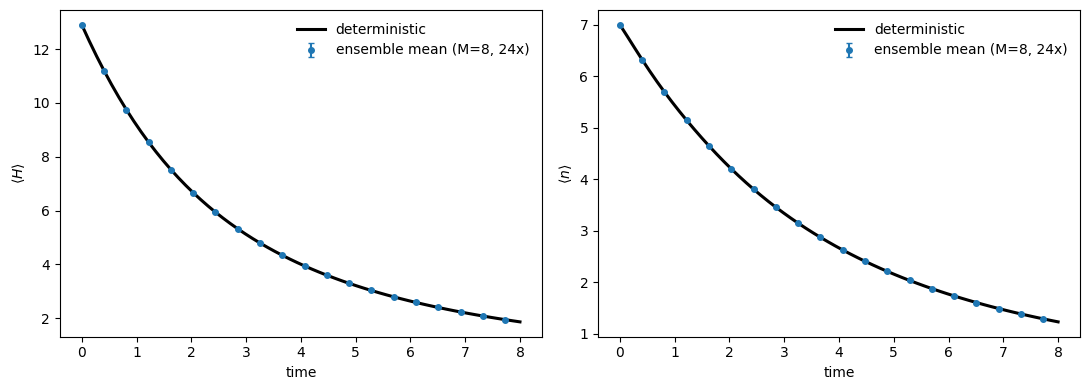

In [6]:
ens = qb.mesolve_ensemble(H, rho0, tlist, c_ops_full, M=8,
                          e_ops=e_ops, n_realizations=24, rng=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k, lbl in enumerate([r"$\langle H\rangle$", r"$\langle n\rangle$"]):
    ax[k].plot(tlist, np.real(det.expect[k]), "k-", lw=2.2, label="deterministic")
    ax[k].errorbar(tlist[::3], ens.expect[k][::3], yerr=ens.sem[k][::3],
                   fmt="o", ms=4, color="tab:blue", capsize=2,
                   label="ensemble mean (M=8, 24x)")
    ax[k].set_xlabel("time"); ax[k].set_ylabel(lbl); ax[k].legend(frameon=False)
fig.tight_layout()

### Mean, error bar, spread, and raw data

`mesolve_ensemble` returns four things per observable:

- `expect[k]` — the **mean** over realizations
- `sem[k]` — the **standard error of the mean** (`std / sqrt(n)`), shrinks as you add realizations; use for error bars on the mean
- `std[k]` — the **standard deviation** across trajectories, characterizing how noisy a *single* bundled run is; does **not** shrink with more realizations
- `samples` — the **raw** per-realization data, shape `(n_realizations, n_e_ops, n_times)`

Because the raw samples are kept, any other spread quantity (your own
fluctuation definition, percentiles, histograms) can be recomputed; the
summary statistics above are just conveniences.

In [7]:
print("samples shape:", ens.samples.shape, "(n_realizations, n_e_ops, n_times)")
print("mean  <H>(t_final):", ens.expect[0][-1])
print("std   <H>(t_final):", ens.std[0][-1], "  (single-trajectory spread)")
print("sem   <H>(t_final):", ens.sem[0][-1], "  (= std / sqrt(n))")

# Verify the relationships directly from the raw data
import numpy as np
assert np.allclose(ens.expect[0], ens.samples[:, 0, :].mean(axis=0))
assert np.allclose(ens.std[0],    ens.samples[:, 0, :].std(axis=0, ddof=1))
print("\nrelationships check out: mean and std recomputed from samples match")

samples shape: (24, 2, 60) (n_realizations, n_e_ops, n_times)
mean  <H>(t_final): 1.8736881968244703
std   <H>(t_final): 0.0019322227851020354   (single-trajectory spread)
sem   <H>(t_final): 0.0003944133244066151   (= std / sqrt(n))

relationships check out: mean and std recomputed from samples match


## 5. Convergence with $M$

As $M$ grows, the bundled estimate approaches the deterministic answer. The
leading error is a **bias** that scales as $1/M$ (eq. 14 of the paper).

M=  2:  max error = 1.600e-02
M=  4:  max error = 8.564e-03
M=  8:  max error = 4.619e-03
M= 16:  max error = 2.036e-03
M= 32:  max error = 9.291e-04


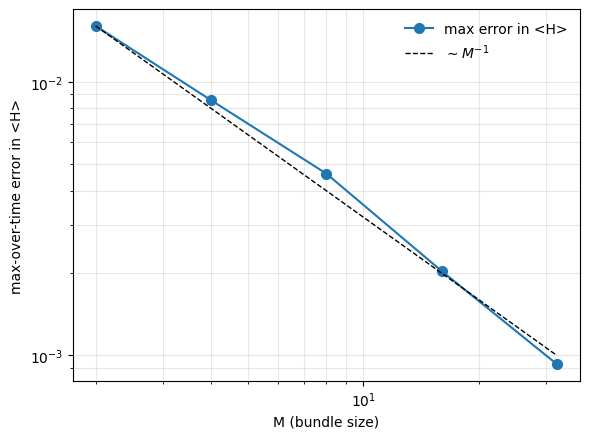

In [8]:
M_values = [2, 4, 8, 16, 32]
truth = np.real(det.expect[0])
errors = []
for M in M_values:
    e = qb.mesolve_ensemble(H, rho0, tlist, c_ops_full, M=M,
                            e_ops=e_ops, n_realizations=24, rng=0)
    errors.append(np.max(np.abs(e.expect[0] - truth)))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(M_values, errors, "o-", lw=1.5, ms=7, label="max error in <H>")
Mref = np.array([M_values[0], M_values[-1]])
ax.loglog(Mref, errors[0]*(Mref/M_values[0])**-1.0, "k--", lw=1, label=r"$\sim M^{-1}$")
ax.set_xlabel("M (bundle size)"); ax.set_ylabel("max-over-time error in <H>")
ax.grid(True, which="both", alpha=0.3); ax.legend(frameon=False)
fig.tight_layout()
for M, e in zip(M_values, errors):
    print(f"M={M:3d}:  max error = {e:.3e}")

> *This section is optional.* The core method is bundle → solve → average; the jackknife below is an extra for squeezing out bias at fixed `M`.

## 6. (Advanced) Bias vs. variance, and the jackknife

The error has two parts: a **bias** (systematic, from finite $M$, $\sim 1/M$)
and a **variance** (random scatter, from finite ensemble, $\sim 1/\sqrt{n}$).
When bias dominates, the **jackknife-2 estimator** (eq. 16) cancels the leading
bias term using sub-bundles of the same draws — often beating a plain larger $M$
at equal cost.

In [9]:
direct = qb.mesolve_ensemble(H, rho0, tlist, c_ops_full, M=8,
                             e_ops=e_ops, n_realizations=24, rng=1)
jack = qb.mesolve_jackknife(H, rho0, tlist, c_ops_full, M=8,
                            e_ops=e_ops, n_realizations=24, rng=1)

err_direct = np.max(np.abs(direct.expect[0] - truth))
err_jack = np.max(np.abs(jack.expect[0] - truth))
print(f"direct  M=8 : max error = {err_direct:.3e}")
print(f"jackknife M=8: max error = {err_jack:.3e}")

direct  M=8 : max error = 4.508e-03
jackknife M=8: max error = 9.473e-04


## 7. Large systems: the `native` backend

QuTiP's `mesolve` builds a Liouvillian superoperator — an $N^2\times N^2$ matrix
per collapse operator — which runs out of memory once $N$ reaches a few dozen
with many operators. The package ships a `native` RK4 backend that steps the
density matrix directly, with memory $O((N_c+1)N^2)$ instead of $O(N_c N^4)$.

Both `mesolve_ensemble` and `mesolve_jackknife` accept `backend="native"`. For
stiff systems (many operators) increase `substeps`.

In [10]:
# Native backend gives the same answer on this small system...
ens_native = qb.mesolve_ensemble(H, rho0, tlist, c_ops_full, M=8,
                                 e_ops=e_ops, n_realizations=8, rng=0,
                                 backend="native", substeps=4)
diff = np.max(np.abs(ens_native.expect[0]
                     - qb.mesolve_ensemble(H, rho0, tlist, c_ops_full, M=8,
                                           e_ops=e_ops, n_realizations=8, rng=0).expect[0]))
print(f"max |native - qutip| (same seeds) = {diff:.2e}")
print("...and on large systems it runs where qutip.mesolve cannot allocate memory.")

max |native - qutip| (same seeds) = 1.26e-08
...and on large systems it runs where qutip.mesolve cannot allocate memory.


## Recap

- `davies_operators(H, X, gamma)` builds collapse operators with the correct
  sign convention.
- `bundle(c_ops, M)` produces $M$ bundled operators; hand them to any solver.
- `mesolve_ensemble` averages realizations and returns mean, `sem`, `std`,
  and the raw `samples`.
- `mesolve_jackknife` (optional, advanced) removes the `O(1/M)` bias at fixed `M`.
- `backend="native"` lifts the memory ceiling for large systems.

The bundled dissipator is an unbiased estimator of the full one, the error
falls as $1/M$ (bias) or $1/\sqrt{n}$ (variance), and the per-step cost drops
from $O(N^5)$ to $O(N^3)$ — the speedup grows with system size.

See `CONVENTIONS.md` for the sign convention and detailed-balance details, and
the paper (JCTC 2025, 21, 4142) for the theory.